In [ ]:
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

RAW_DATA = PROJECT_ROOT / "Data1"
PROCESSED_DATA = PROJECT_ROOT / "data" / "processed"
OUTPUTS = PROJECT_ROOT / "outputs"
MODELS = PROJECT_ROOT / "models"

PROCESSED_DATA.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Raw data:", RAW_DATA)
print("Processed data:", PROCESSED_DATA)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

from skimage.filters.rank import entropy
from skimage.morphology import disk

print("Libraries imported successfully!")

In [2]:
import os

data_folder = "data"

for file in os.listdir(data_folder):
    print(file)

ch2_ohr_ncp_20240316T2008014680_d_img_d18.img
.ipynb_checkpoints
ch2_ohr_ncp_20240316T2008014680_d_img_d18.xml


In [3]:
import os

print(os.listdir("Data"))

['ch2_ohr_ncp_20240316T2008014680_d_img_d18.img', '.ipynb_checkpoints', 'ch2_ohr_ncp_20240316T2008014680_d_img_d18.xml']


In [4]:
import os

files = os.listdir("Data")

xml_file = [f for f in files if f.endswith(".xml")][0]
img_file = [f for f in files if f.endswith(".img")][0]

print(xml_file)
print(img_file)

ch2_ohr_ncp_20240316T2008014680_d_img_d18.xml
ch2_ohr_ncp_20240316T2008014680_d_img_d18.img


In [5]:
import xml.etree.ElementTree as ET
import os

xml_path = os.path.join("Data", xml_file)

tree = ET.parse(xml_path)
root = tree.getroot()

print("XML loaded successfully!")

XML loaded successfully!


In [6]:
ns = {
    "pds": "http://pds.nasa.gov/pds4/pds/v1",
    "isda": "https://isda.issdc.gov.in/pds4/isda/v1"
}

lines = int(root.find(".//pds:Axis_Array[pds:axis_name='Line']/pds:elements", ns).text)
samples = int(root.find(".//pds:Axis_Array[pds:axis_name='Sample']/pds:elements", ns).text)
resolution = float(root.find(".//isda:pixel_resolution", ns).text)

print("Lines:", lines)
print("Samples:", samples)
print("Resolution:", resolution, "m/pixel")

Lines: 101074
Samples: 12000
Resolution: 0.2 m/pixel


In [7]:
import numpy as np
import matplotlib.pyplot as plt
import os

img_path = os.path.join("Data", img_file)

img = np.memmap(img_path, dtype=np.uint8, mode="r", shape=(lines, samples))

print("Image loaded safely!")
print("Shape:", img.shape)

Image loaded safely!
Shape: (101074, 12000)


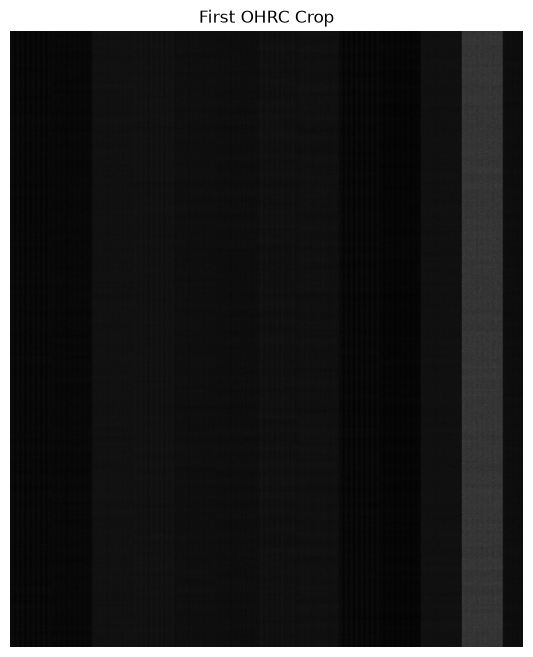

In [8]:
crop = img[30000:36000, 4000:9000]

plt.figure(figsize=(10,8))
plt.imshow(crop, cmap="gray")
plt.axis("off")
plt.title("First OHRC Crop")
plt.show()

# 1. Find Useful Illuminated Region

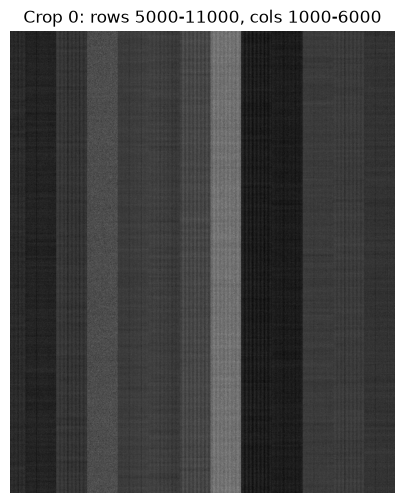

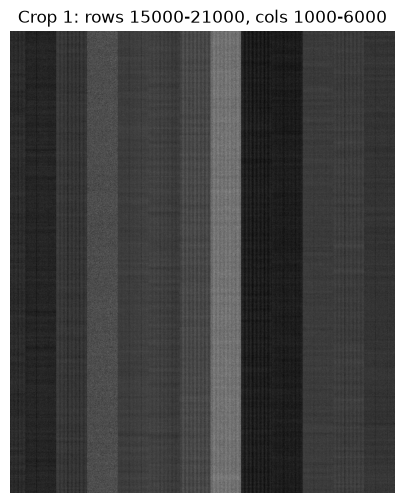

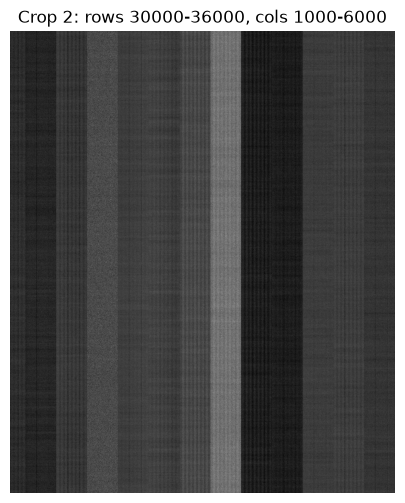

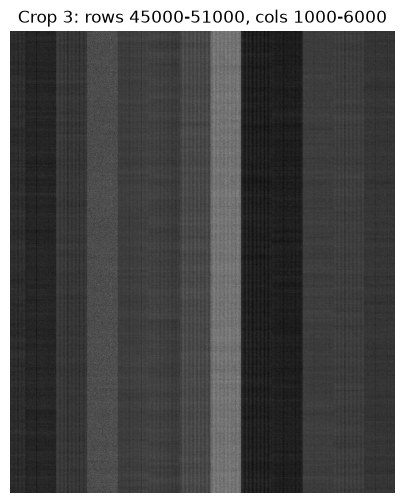

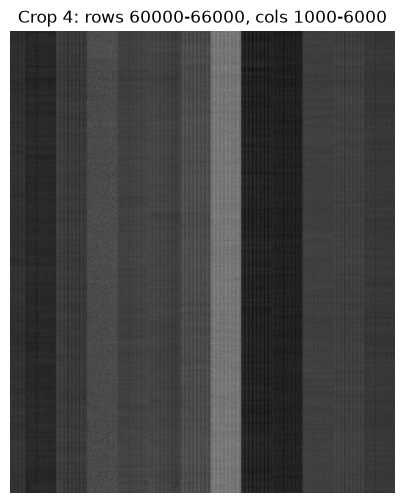

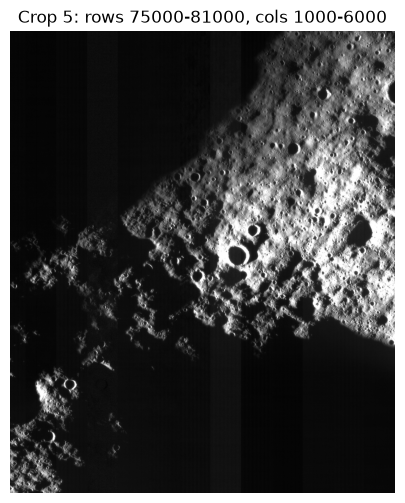

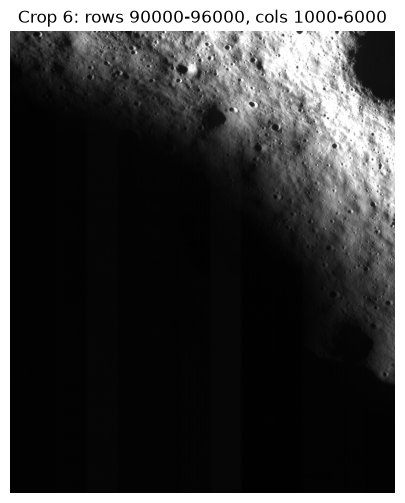

In [9]:
import matplotlib.pyplot as plt

# Try multiple crop positions across the OHRC strip
crop_boxes = [
    (5000, 11000, 1000, 6000),
    (15000, 21000, 1000, 6000),
    (30000, 36000, 1000, 6000),
    (45000, 51000, 1000, 6000),
    (60000, 66000, 1000, 6000),
    (75000, 81000, 1000, 6000),
    (90000, 96000, 1000, 6000),
]

for i, (r1, r2, c1, c2) in enumerate(crop_boxes):
    crop = img[r1:r2, c1:c2]
    p2, p98 = np.percentile(crop, (2, 98))
    enhanced = np.clip((crop - p2) / (p98 - p2 + 1e-6), 0, 1)

    plt.figure(figsize=(8, 6))
    plt.imshow(enhanced, cmap="gray")
    plt.axis("off")
    plt.title(f"Crop {i}: rows {r1}-{r2}, cols {c1}-{c2}")
    plt.show()

# 1. Find Useful Illuminated Region

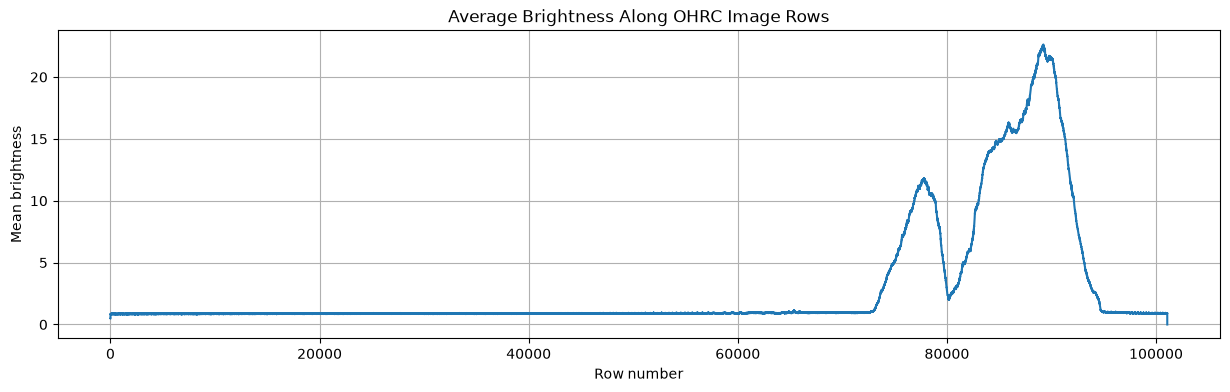

In [10]:
# Average brightness for every row of the OHRC image
row_mean = img.mean(axis=1)

plt.figure(figsize=(15,4))
plt.plot(row_mean)
plt.title("Average Brightness Along OHRC Image Rows")
plt.xlabel("Row number")
plt.ylabel("Mean brightness")
plt.grid(True)
plt.show()

In [11]:
threshold = row_mean.mean() + row_mean.std()

good_rows = np.where(row_mean > threshold)[0]

print("Threshold:", threshold)
print("First useful row:", good_rows[0])
print("Last useful row:", good_rows[-1])
print("Number of useful rows:", len(good_rows))

Threshold: 7.808273330480249
First useful row: 76039
Last useful row: 92483
Number of useful rows: 13116


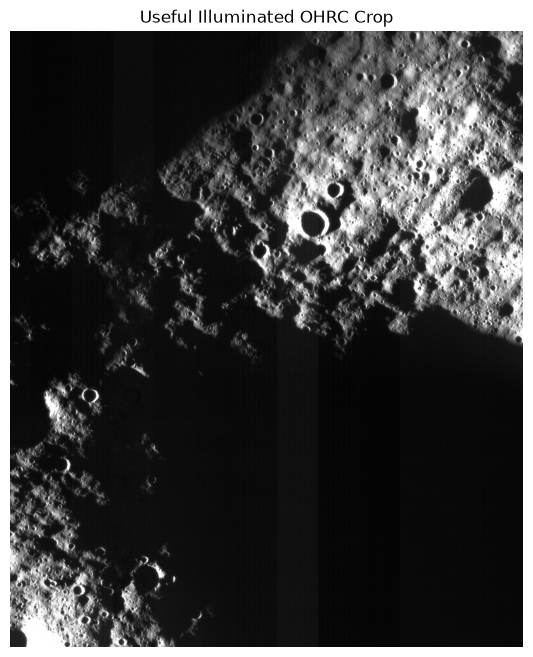

In [12]:
r1 = good_rows[0]
r2 = min(r1 + 6000, lines)

c1 = 1000
c2 = 6000

crop = img[r1:r2, c1:c2]

p2, p98 = np.percentile(crop, (2, 98))
enhanced = np.clip((crop - p2) / (p98 - p2 + 1e-6), 0, 1)
gray = (enhanced * 255).astype(np.uint8)

plt.figure(figsize=(10,8))
plt.imshow(gray, cmap="gray")
plt.axis("off")
plt.title("Useful Illuminated OHRC Crop")
plt.show()

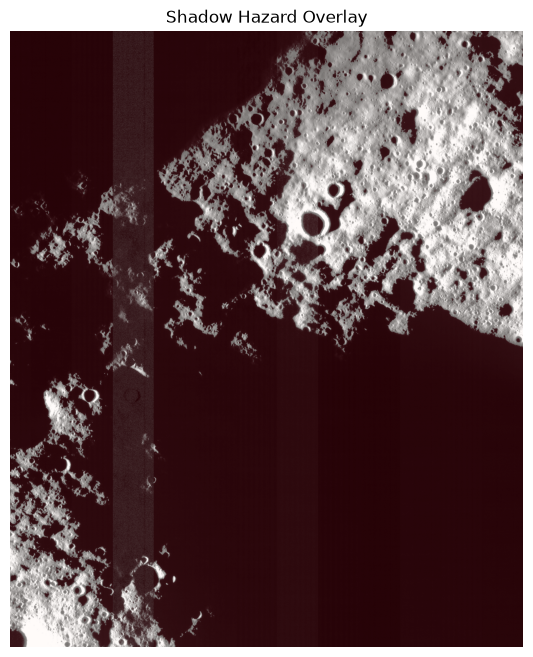

In [13]:
# Shadow Detection

shadow_threshold = 0.15   # pixels darker than this are treated as shadow
shadow_mask = enhanced < shadow_threshold

plt.figure(figsize=(10,8))
plt.imshow(gray, cmap="gray")
plt.imshow(shadow_mask, cmap="Reds", alpha=0.35)
plt.axis("off")
plt.title("Shadow Hazard Overlay")
plt.show()

In [14]:
shadow_percentage = (shadow_mask.sum() / shadow_mask.size) * 100

print("Shadow percentage in crop:", round(shadow_percentage, 2), "%")

Shadow percentage in crop: 71.37 %


# 3. Surface Roughness / Texture Analysis

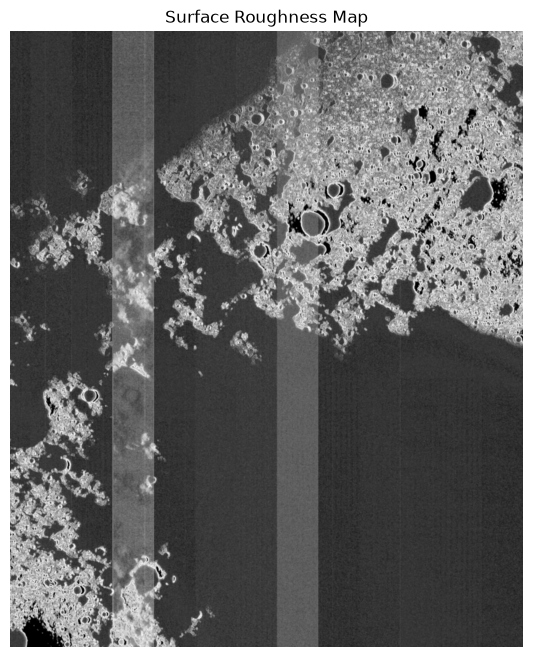

In [15]:
from skimage.filters.rank import entropy
from skimage.morphology import disk

texture = entropy(gray, disk(7))
texture_norm = texture / texture.max()

plt.figure(figsize=(10,8))
plt.imshow(texture_norm, cmap="gray")
plt.axis("off")
plt.title("Surface Roughness Map")
plt.show()

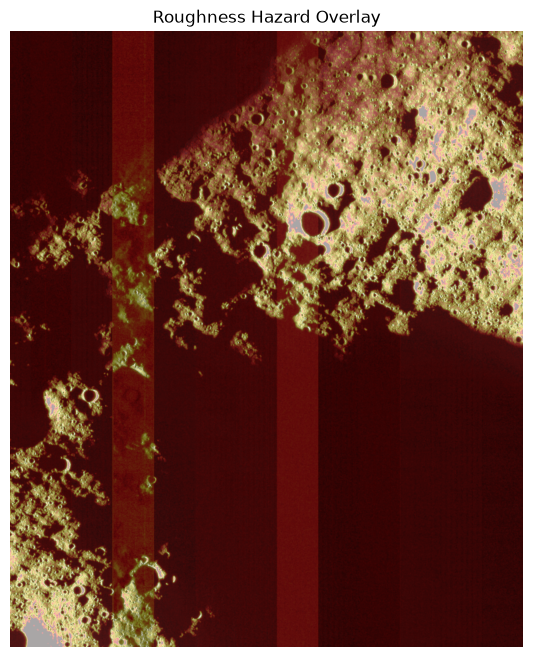

In [16]:
plt.figure(figsize=(10,8))
plt.imshow(gray, cmap="gray")
plt.imshow(texture_norm, cmap="hot", alpha=0.35)
plt.axis("off")
plt.title("Roughness Hazard Overlay")
plt.show()

In [17]:
mean_roughness = texture_norm.mean()

print("Mean roughness score:", round(mean_roughness, 3))

Mean roughness score: 0.357


In [18]:
import numpy as np
import matplotlib.pyplot as plt

def analyze_crop(crop):
    gray = crop.astype(np.float32)

    # shadow: very dark pixels
    shadow_pixels = gray < 20
    shadow_percentage = np.sum(shadow_pixels) / gray.size * 100

    # brightness
    mean_brightness = np.mean(gray)

    # roughness using gradient
    gy, gx = np.gradient(gray)
    roughness = np.mean(np.sqrt(gx**2 + gy**2)) / 255

    # scores
    shadow_score = shadow_percentage / 100
    smoothness_score = 1 - roughness
    brightness_score = mean_brightness / 255

    ice_candidate_score = (
        0.4 * shadow_score +
        0.3 * smoothness_score +
        0.3 * brightness_score
    )

    return {
        "roughness": roughness,
        "shadow_percentage": shadow_percentage,
        "mean_brightness": mean_brightness,
        "ice_candidate_score": ice_candidate_score
    }

In [ ]:
import os
import numpy as np

os.makedirs("../data/processed", exist_ok=True)

np.save("../data/processed/useful_image.npy", useful_image)

print("Saved useful_image:", useful_image.shape)

In [20]:
%whos

Variable            Type           Data/Info
--------------------------------------------
ET                  module         <module 'xml.etree.Elemen<...>ml/etree/ElementTree.py'>
analyze_crop        function       <function analyze_crop at 0x12da827a0>
c1                  int            1000
c2                  int            6000
crop                memmap         [[ 2  0  1 ... 11 11 11]\<...> [ 5  4  4 ...  1  1  1]]
crop_boxes          list           n=7
cv2                 module         <module 'cv2' from '/opt/<...>ackages/cv2/__init__.py'>
data_folder         str            data
disk                function       <function disk at 0x11cf51940>
enhanced            ndarray        6000x5000: 30000000 elems, type `float64`, 240000000 bytes (228.8818359375 Mb)
entropy             function       <function entropy at 0x11da454e0>
file                str            ch2_ohr_ncp_20240316T2008014680_d_img_d18.xml
files               list           n=3
good_rows           ndarray        

In [22]:
first_useful_row = 76039
last_useful_row = 92483

useful_image = img[first_useful_row:last_useful_row, :]

print("Useful image created")
print("Shape:", useful_image.shape)

Useful image created
Shape: (16444, 12000)


In [23]:
import os
import numpy as np

os.makedirs("data/processed", exist_ok=True)

np.save("data/processed/useful_image.npy", useful_image)

print("Saved useful_image.npy")
print("Shape:", useful_image.shape)

Saved useful_image.npy
Shape: (16444, 12000)
